In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy
import importlib
import phise
import grip
importlib.reload(phise)

No module named 'sbi'
GRIP is imported without NPE features


<module 'phise' from 'E:\\PHISE\\src\\phise\\__init__.py'>

In [2]:
# Context definition

ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.fov = 0.1 * u.deg

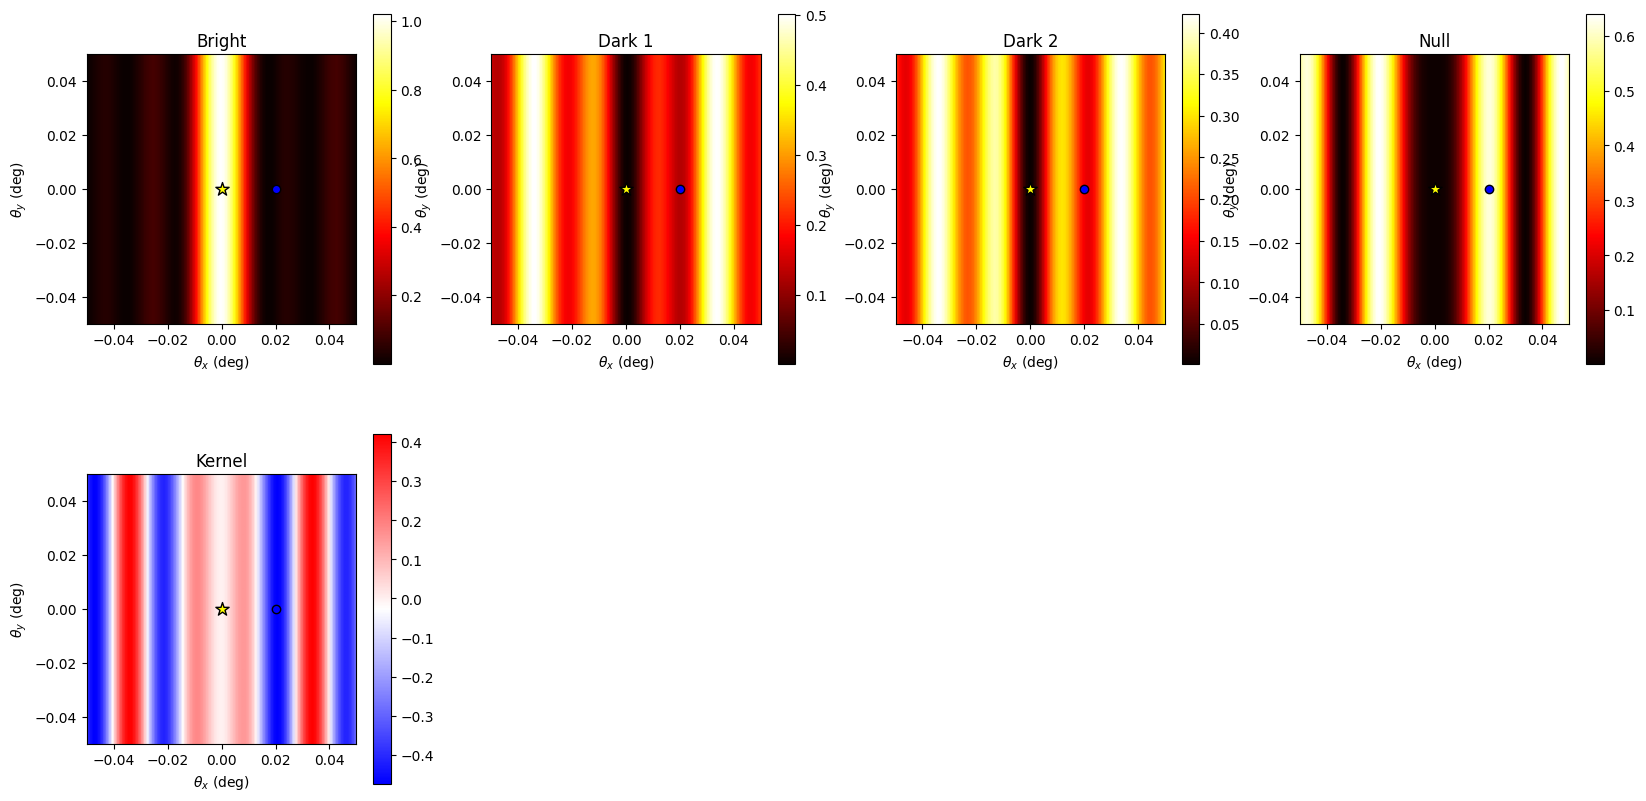


Tunable Laser Star throughputs:
----------
   Bright: 101.89%,   Dark 1: 0.31%,   Dark 2: 0.24%,   Null: 0.52%
   Kernel: -0.29%
Unnamed Companion throughputs:
----------
   Bright: 1.40%,   Dark 1: 12.91%,   Dark 2: 14.82%,   Null: 61.63%
   Kernel: -46.81%


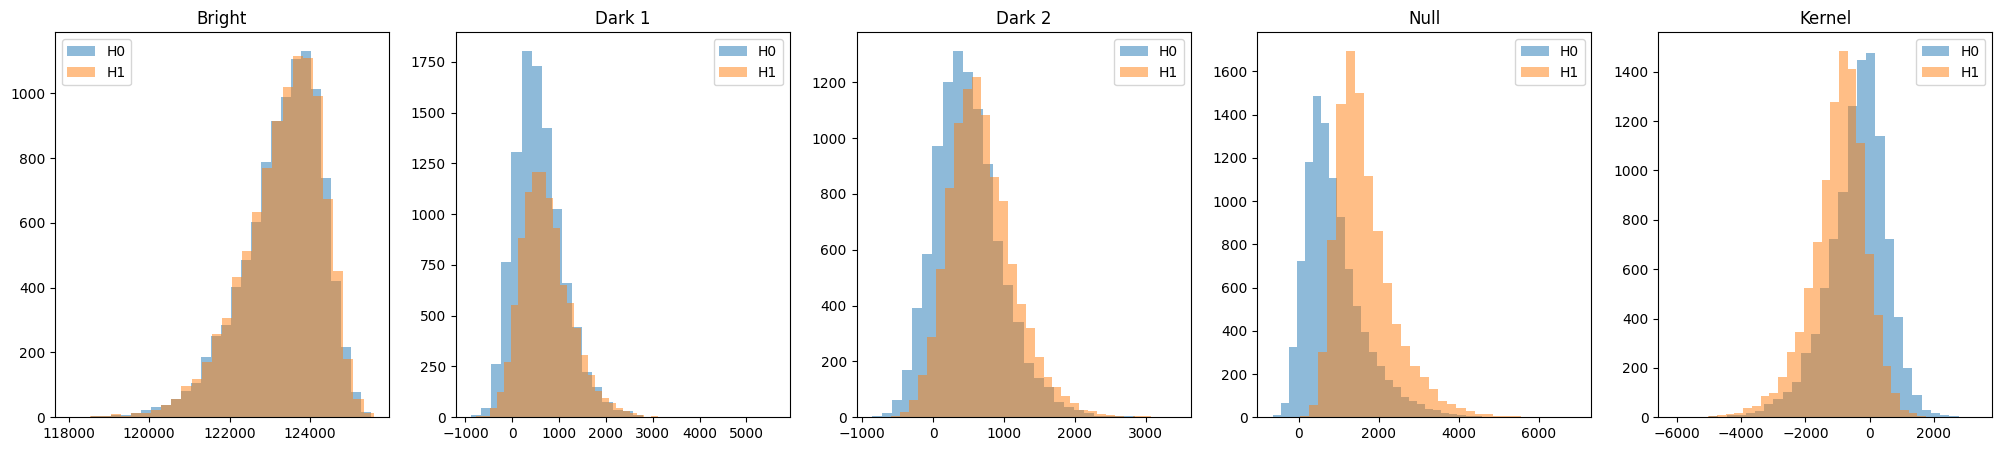

In [3]:


ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.fov = 0.1 * u.deg
ctx.chip.calibrate()
ctx.Γ = 20 * u.nm # 1nm of upstream piston rms
ctx_h0 = copy(ctx)
ctx_h0.target.companions = []
ctx_h1 = copy(ctx)
ctx_h1.target.companions = [phise.Companion(1e-2, 0.02*u.deg, 0*u.deg)]

ctx_h1.plot_transmission_maps(N=100)

N = 10_000

n_raw = ctx.chip.nb_raw_outputs
n_processed = ctx.chip.nb_processed_outputs

data_h0 = np.empty((n_raw + n_processed, N))
data_h1 = np.empty((n_raw + n_processed, N))

for i in range(N):
    h0_outs = ctx_h0.observe()
    h1_outs = ctx_h1.observe()
    data_h0[:n_raw, i] = h0_outs
    data_h1[:n_raw, i] = h1_outs
    data_h0[n_raw:, i] = ctx_h0.chip.process_outputs(h0_outs)
    data_h1[n_raw:, i] = ctx_h1.chip.process_outputs(h1_outs)

titles = ['Bright', 'Dark 1', 'Dark 2', 'Null', 'Kernel']
fig, axs = plt.subplots(1, n_raw + n_processed, figsize=((n_raw + n_processed) * 5, 5))
for i in range(n_raw + n_processed):
    axs[i].hist(data_h0[i, :], bins=30, alpha=0.5, label='H0')
    axs[i].hist(data_h1[i, :], bins=30, alpha=0.5, label='H1')
    axs[i].set_title(titles[i])
    axs[i].legend()

In [24]:
ctx_model = copy(ctx_h1)
na = ctx_model.target.companions[0].c
piston_atmo_rms = ctx_model.Γ.to(u.nm).value
wavelength = ctx_model.interferometer.λ.to(u.nm).value
nb_outs = ctx_model.chip.nb_raw_outputs + ctx_model.chip.nb_processed_outputs

N = 10_000

def phise_sim(ctx):
    raw_outs = ctx.observe()
    proc_outs = ctx.chip.process_outputs(raw_outs)
    return np.concatenate((raw_outs, proc_outs))

def grip_model(na, wavelength, wl_idx, piston_atmo_rms):
    na = na[0]
    ctx_model.Γ = piston_atmo_rms * u.nm
    ctx_model.interferometer.λ = wavelength * u.nm
    ctx_model.target.companions[0].c = na
    data_grip = np.empty((N, nb_outs))
    histograms = []
    for i in range(N):
        data_grip[i,:] = phise_sim(ctx_model)
    for o in range(nb_outs):
        histograms.append(np.histogram(data_grip[:, o], bins=int(np.sqrt(N)/2)))
    return np.array(histograms)

data_phise = np.empty((N, nb_outs))
for i in range(N):
    data_phise[i,:] = phise_sim(ctx_model)
grip_hists = grip_model([na], wavelength, None, piston_atmo_rms)

fig, axs = plt.subplots(1, nb_outs, figsize=(nb_outs * 5, 5))
for o in range(nb_outs):
    # axs[o].hist(data_phise[:, o], bins=int(np.sqrt(N)/2), alpha=0.5, label='PHISE sim')
    axs[o].hist(grip_hists[o][0], bins=grip_hists[o][1], alpha=0.5, label='GRIP model')
    axs[o].set_title(titles[o])
    axs[o].legend()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (5, 2) + inhomogeneous part.

In [22]:
def grip_model_oneout(*args, **kwargs):
    return grip_model(*args, **kwargs)[3]

In [23]:
grip.log_multinomial([na], data_phise, grip_model, wavelength, None, piston_atmo_rms)

AttributeError: 'tuple' object has no attribute 'reshape'